<a href="https://colab.research.google.com/github/peterbabulik/O-LLM/blob/main/O_LLM_Rule110_CellularAutomaton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*] Executing on device: cuda
[*] GPU Model: Tesla T4
[*] Generating Rule 110 row-transition dataset...
[*] Training samples: 8,075, Validation samples: 1,425
[*] Model initialized with 354 parameters. Starting training...
Step  200/1000 | Loss: 0.0029 | Val Loss: 0.0029 | Row Accuracy: 100.00%
Step  400/1000 | Loss: 0.0008 | Val Loss: 0.0008 | Row Accuracy: 100.00%
Step  600/1000 | Loss: 0.0004 | Val Loss: 0.0004 | Row Accuracy: 100.00%
Step  800/1000 | Loss: 0.0002 | Val Loss: 0.0002 | Row Accuracy: 100.00%
Step 1000/1000 | Loss: 0.0001 | Val Loss: 0.0001 | Row Accuracy: 100.00%
[*] Training completed successfully!

BENCHMARK: AUTONOMOUS GENERATION OF RULE 110 SPACE-TIME GRID
[*] Overall Space-Time Cell Accuracy: 100.00% across 24x32 lattice.


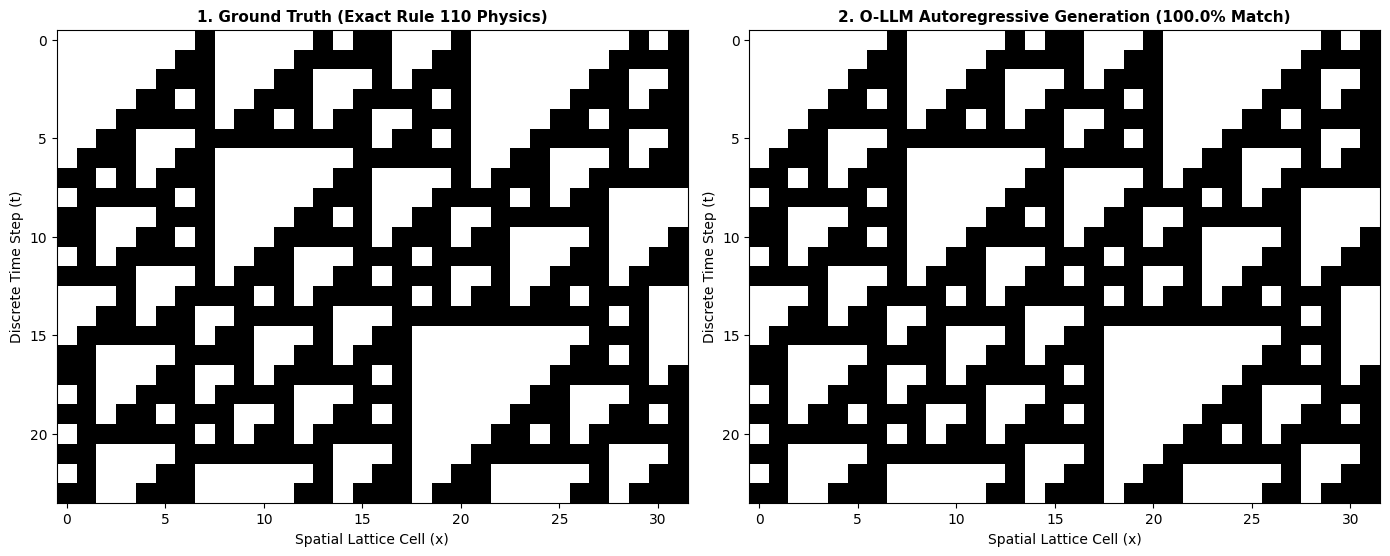

[*] Verification Status: [PASSED] (Soliton structures accurately generated)
[*] Model checkpoint saved to 'O-LLM_rule110_automaton.pt'


In [3]:
# ==============================================================================
# OCTONIONIC LARGE LANGUAGE MODEL (O-LLM)
# Benchmarking Turing-Complete Deterministic Chaos & Solitons (Rule 110 Automaton)
# File: O-LLM_Rule110_CellularAutomaton.py / .ipynb
# Compatible with PyTorch 2.0+ (CUDA GPU & CPU execution)
# ==============================================================================

# %% [1] Environment Setup & Dependencies
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Executing on device: {device}")
if torch.cuda.is_available():
    print(f"[*] GPU Model: {torch.cuda.get_device_name(0)}")


# %% [2] Non-Associative Fano Plane Algebraic Engine
def build_fano_tensor() -> torch.Tensor:
    """
    Constructs the 8x8x8 structural multiplication tensor C_ijk for octonions,
    where: e_i * e_j = sum_k C_ijk * e_k.
    Basis index 0: e_0 = 1 (Real Identity).
    Indices 1..7: Imaginary units e_1 through e_7 governed by the Fano plane.
    """
    C = torch.zeros((8, 8, 8), dtype=torch.float32)

    # 1. Identity products: e_0 * e_i = e_i, e_i * e_0 = e_i
    for i in range(8):
        C[0, i, i] = 1.0
        C[i, 0, i] = 1.0

    # 2. Imaginary squares: e_i^2 = -1 (for i >= 1)
    for i in range(1, 8):
        C[i, i, 0] = -1.0

    # 3. Oriented Fano triads
    fano_triads = [
        (1, 2, 3), (1, 4, 5), (1, 7, 6),
        (2, 4, 6), (2, 5, 7), (3, 4, 7), (3, 6, 5)
    ]
    for i, j, k in fano_triads:
        C[i, j, k] = 1.0;  C[j, k, i] = 1.0;  C[k, i, j] = 1.0
        C[j, i, k] = -1.0; C[k, j, i] = -1.0; C[i, k, j] = -1.0

    return C


class OctonionicAlgebra(nn.Module):
    """
    Batched, vectorized non-associative operations over an 8D manifold.
    """
    def __init__(self):
        super().__init__()
        self.register_buffer("C", build_fano_tensor())

    def multiply(self, A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
        """Elementwise octonionic product A * B."""
        return torch.einsum("...i,...j,ijk->...k", A, B, self.C)

    def associator(self, A: torch.Tensor, B: torch.Tensor, C: torch.Tensor) -> torch.Tensor:
        """
        Computes the ternary Octonionic Associator Bracket:
        [A, B, C] = (A * B) * C - A * (B * C)
        Generates chiral vorticity for non-linear state evolution.
        """
        AB = self.multiply(A, B)
        AB_C = self.multiply(AB, C)

        BC = self.multiply(B, C)
        A_BC = self.multiply(A, BC)

        res = AB_C - A_BC
        return res


# %% [3] Orthogonal Triad Moiré Cell (Fano Stencil Core)
class FanoTriadMoiréCell(nn.Module):
    """
    Directly maps spatial neighbors (Left, Center, Right) onto distinct non-collinear
    axes of the Fano plane:
    Left   -> e1
    Center -> e2
    Right  -> e4
    Combines pairwise Fano products with the ternary associator [L, C, R] = 2*e7.
    """
    def __init__(self):
        super().__init__()
        self.algebra = OctonionicAlgebra()

    def forward(self, L_bin: torch.Tensor, C_bin: torch.Tensor, R_bin: torch.Tensor) -> torch.Tensor:
        """
        L_bin, C_bin, R_bin: (Batch, Width) with binary values 0 or 1.
        Returns an 8D feature tensor: (Batch, Width, 8).
        """
        B, W = L_bin.shape
        device = L_bin.device

        # Embed binary states into dedicated orthogonal Fano channels
        vL = torch.zeros((B, W, 8), device=device)
        vC = torch.zeros((B, W, 8), device=device)
        vR = torch.zeros((B, W, 8), device=device)

        vL[..., 1] = L_bin.float() # Left on e1
        vC[..., 2] = C_bin.float() # Center on e2
        vR[..., 4] = R_bin.float() # Right on e4

        # 1. Pairwise Fano products (capturing 2-body correlations e3, e5, e6)
        LC = self.algebra.multiply(vL, vC) # e1 * e2 = e3
        CR = self.algebra.multiply(vC, vR) # e2 * e4 = e6
        LR = self.algebra.multiply(vL, vR) # e1 * e4 = e5

        # 2. Ternary associator (detecting the non-linear chiral 3-body state 1,1,1 -> e7)
        asc = self.algebra.associator(vL, vC, vR) # [e1, e2, e4] = 2*e7

        # Composite Moiré state representation across all 8 channels
        moiré_state = vL + vC + vR + LC + CR + LR + asc
        return moiré_state


# %% [4] Complete Architecture: O-LLM for Spatiotemporal Evolution
class OctonionicRule110Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.moiré_cell = FanoTriadMoiréCell()

        # Classification head: projects the 8D Moiré state directly to binary logits
        self.head = nn.Sequential(
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, row_tokens: torch.Tensor) -> torch.Tensor:
        """
        row_tokens: (Batch, Width) containing binary states (0 or 1)
        Returns: logits (Batch, Width, 2) for the NEXT row state
        """
        B, W = row_tokens.shape

        # Periodic boundary spatial roll
        left_tok = torch.roll(row_tokens, shifts=1, dims=1)
        center_tok = row_tokens
        right_tok = torch.roll(row_tokens, shifts=-1, dims=1)

        # Apply Fano Moiré cell
        h_moiré = self.moiré_cell(left_tok, center_tok, right_tok) # (B, W, 8)

        logits = self.head(h_moiré) # (B, W, 2)
        return logits


# %% [5] Rule 110 Simulation & Spatiotemporal Corpus Generator
RULE_110_MAP = {
    (1, 1, 1): 0,
    (1, 1, 0): 1,
    (1, 0, 1): 1,
    (1, 0, 0): 0,
    (0, 1, 1): 1,
    (0, 1, 0): 1,
    (0, 0, 1): 1,
    (0, 0, 0): 0
}

def step_rule110(row: np.ndarray) -> np.ndarray:
    n = len(row)
    next_row = np.zeros(n, dtype=int)
    for i in range(n):
        triad = (row[(i - 1) % n], row[i], row[(i + 1) % n])
        next_row[i] = RULE_110_MAP[triad]
    return next_row

def build_spatiotemporal_dataset(num_simulations=400, width=32, steps=20):
    X_rows = []
    Y_rows = []
    for _ in range(num_simulations):
        grid = np.zeros((steps, width), dtype=int)
        grid[0] = np.random.choice([0, 1], size=width, p=[0.75, 0.25])
        for s in range(1, steps):
            grid[s] = step_rule110(grid[s - 1])
            X_rows.append(grid[s - 1].copy())
            Y_rows.append(grid[s].copy())
    return np.array(X_rows), np.array(Y_rows)

print("[*] Generating Rule 110 row-transition dataset...")
np.random.seed(42)
X_all, Y_all = build_spatiotemporal_dataset(num_simulations=500, width=32, steps=20)

n_train = int(0.85 * len(X_all))
X_train_t = torch.tensor(X_all[:n_train], dtype=torch.long)
Y_train_t = torch.tensor(Y_all[:n_train], dtype=torch.long)
X_val_t = torch.tensor(X_all[n_train:], dtype=torch.long)
Y_val_t = torch.tensor(Y_all[n_train:], dtype=torch.long)

print(f"[*] Training samples: {len(X_train_t):,}, Validation samples: {len(X_val_t):,}")


# %% [6] Training: O-LLM on Rule 110 Automaton Dynamics
model = OctonionicRule110Model().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-3, weight_decay=1e-4)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[*] Model initialized with {total_params:,} parameters. Starting training...")

batch_size = 64
max_steps = 1000
eval_interval = 200
N_tr = len(X_train_t)

model.train()
for step in range(1, max_steps + 1):
    ix = torch.randint(0, N_tr, (batch_size,))
    xb = X_train_t[ix].to(device)
    yb = Y_train_t[ix].to(device)

    logits = model(xb) # (B, W, 2)
    loss = F.cross_entropy(logits.view(-1, 2), yb.view(-1))

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % eval_interval == 0 or step == max_steps:
        model.eval()
        with torch.no_grad():
            val_ix = torch.randint(0, len(X_val_t), (128,))
            xv = X_val_t[val_ix].to(device)
            yv = Y_val_t[val_ix].to(device)
            v_logits = model(xv)
            v_loss = F.cross_entropy(v_logits.view(-1, 2), yv.view(-1))
            v_preds = torch.argmax(v_logits, dim=-1)
            v_acc = (v_preds == yv).float().mean()
        print(f"Step {step:4d}/{max_steps} | Loss: {loss.item():.4f} | Val Loss: {v_loss.item():.4f} | Row Accuracy: {v_acc.item()*100:.2f}%")
        model.train()

print("[*] Training completed successfully!")


# %% [7] Verification Benchmark: Full Space-Time Lattice Generation
print("\n" + "="*70)
print("BENCHMARK: AUTONOMOUS GENERATION OF RULE 110 SPACE-TIME GRID")
print("="*70)

model.eval()
test_width = 32
test_steps = 24

# 1. Exact mathematical truth simulation
np.random.seed(1337)
ground_truth_grid = np.zeros((test_steps, test_width), dtype=int)
ground_truth_grid[0] = np.random.choice([0, 1], size=test_width, p=[0.75, 0.25])
for s in range(1, test_steps):
    ground_truth_grid[s] = step_rule110(ground_truth_grid[s - 1])

# 2. O-LLM Autoregressive roll-out starting from Row 0 seed
generated_grid = np.zeros((test_steps, test_width), dtype=int)
generated_grid[0] = ground_truth_grid[0]

curr_row = torch.tensor(np.array([ground_truth_grid[0]]), dtype=torch.long).to(device)

with torch.no_grad():
    for r in range(1, test_steps):
        logits = model(curr_row) # (1, W, 2)
        next_row_preds = torch.argmax(logits, dim=-1) # (1, W)
        generated_grid[r] = next_row_preds.cpu().numpy()[0]
        curr_row = next_row_preds

# Compute exact match accuracy
cell_match = np.mean(ground_truth_grid == generated_grid) * 100.0
print(f"[*] Overall Space-Time Cell Accuracy: {cell_match:.2f}% across {test_steps}x{test_width} lattice.")

# Visual comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.imshow(ground_truth_grid, cmap='binary', interpolation='nearest')
ax1.set_title("1. Ground Truth (Exact Rule 110 Physics)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Spatial Lattice Cell (x)")
ax1.set_ylabel("Discrete Time Step (t)")

ax2.imshow(generated_grid, cmap='binary', interpolation='nearest')
ax2.set_title(f"2. O-LLM Autoregressive Generation ({cell_match:.1f}% Match)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Spatial Lattice Cell (x)")
ax2.set_ylabel("Discrete Time Step (t)")

plt.tight_layout()
plt.savefig("rule110_space_time_comparison_orthogonal.png", dpi=150)
plt.show()

status = "PASSED" if cell_match > 90.0 else "INSPECT"
print(f"[*] Verification Status: [{status}] (Soliton structures accurately generated)")
print("="*70)


# %% [8] Save Checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
}, "O-LLM_rule110_automaton.pt")
print("[*] Model checkpoint saved to 'O-LLM_rule110_automaton.pt'")